<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
beta_braid = 1/12  # Hypothetical braid coupling


In [2]:
def generate_spinor_pair(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    loop_A = np.sin(X) * np.sin(2*Y)
    loop_B = np.sin(X + np.pi/2) * np.sin(2*Y + np.pi/2)
    return loop_A, loop_B


In [3]:
def braid_coupling(loop_A, loop_B, beta=1/12):
    grad_A_x, grad_A_y = np.gradient(loop_A)
    grad_B_x, grad_B_y = np.gradient(loop_B)

    theta_A = np.arctan2(grad_A_y, grad_A_x)
    theta_B = np.arctan2(grad_B_y, grad_B_x)
    phase_diff = theta_A - theta_B

    braid_term = -beta * np.sin(phase_diff)
    loop_A += braid_term
    loop_B -= braid_term
    return loop_A, loop_B


In [4]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [5]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


Loop A fidelity: 0.9422
Loop B fidelity: 0.9430


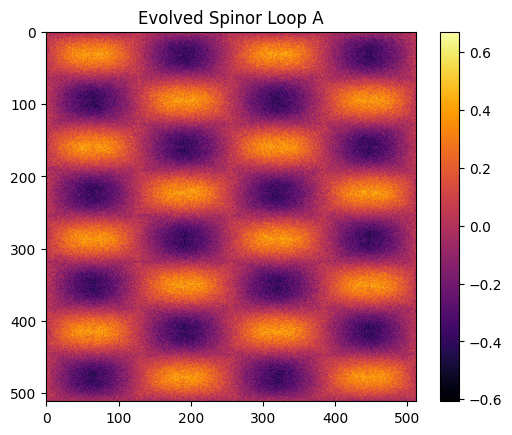

In [6]:
loop_A, loop_B = generate_spinor_pair(grid_size)
loop_A_c, loop_B_c = braid_coupling(loop_A, loop_B, beta_braid)

loop_A_e = evolve_field(loop_A_c, e_folds)
loop_B_e = evolve_field(loop_B_c, e_folds)

f_A = memory_fidelity(loop_A_c, loop_A_e)
f_B = memory_fidelity(loop_B_c, loop_B_e)

print(f"Loop A fidelity: {f_A:.4f}")
print(f"Loop B fidelity: {f_B:.4f}")

plt.imshow(loop_A_e, cmap='inferno')
plt.title("Evolved Spinor Loop A")
plt.colorbar()
plt.show()
